## 🌳 Árvore de Decisão — Resumo Essencial

### 📌 Escala dos dados
- Não precisa padronização ou normalização.
- Divide por regras do tipo: `feature <= valor`.
- Importa a ordem dos valores, não a escala.
- Não usa distância.

---

### 📌 Principal risco: Overfitting
A árvore pode:
- Crescer até Gini = 0
- Memorizar ruído
- Perder capacidade de generalização

**Controle de complexidade:**
- `max_depth`
- `min_samples_split`
- `min_samples_leaf`
- `ccp_alpha` (poda)

---

### 📌 Sensibilidade
- Sensível a ruído e outliers.
- Pequenas variações podem mudar a estrutura.
- Random Forest reduz essa instabilidade.

---

### 📌 Dados desbalanceados
- Pode favorecer classe majoritária.
- Accuracy pode enganar.

Avaliar com:
- Precision
- Recall
- F1-score
- Matriz de confusão

Usar se necessário:
- `class_weight="balanced"`

---

### 📌 Variáveis categóricas
- sklearn não aceita strings diretamente.
- Necessário encoding:
  - OneHotEncoder
  - LabelEncoder

---

### 🎯 Essência Técnica

✔ Baseada em regras  
✔ Alta interpretabilidade (se rasa)  
✔ Propensa a overfitting  
✔ Não depende de escala  
✔ Precisa controle de complexidade  

In [ ]:
# =========================
# 1️⃣ IMPORTAR BIBLIOTECAS
# =========================
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report


# =========================
# 2️⃣ IMPORTAR DATASET
# =========================
import kagglehub

# Download latest version
path = kagglehub.dataset_download("laotse/credit-risk-dataset")

print("Path to dataset files:", path)
df = pd.read_csv(f"{path}/credit_risk_dataset.csv")
display(df)

# # Transformar em DataFrame
# df = pd.DataFrame(iris.data, columns=iris.feature_names)
# df["target"] = iris.target

# print(df.head())

Path to dataset files: C:\Users\joth1\.cache\kagglehub\datasets\laotse\credit-risk-dataset\versions\1


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4
...,...,...,...,...,...,...,...,...,...,...,...,...
32576,57,53000,MORTGAGE,1.0,PERSONAL,C,5800,13.16,0,0.11,N,30
32577,54,120000,MORTGAGE,4.0,PERSONAL,A,17625,7.49,0,0.15,N,19
32578,65,76000,RENT,3.0,HOMEIMPROVEMENT,B,35000,10.99,1,0.46,N,28
32579,56,150000,MORTGAGE,5.0,PERSONAL,B,15000,11.48,0,0.10,N,26


In [ ]:
df = df.rename(columns={
    "person_age": "idade",
    "person_income": "renda_anual",
    "person_home_ownership": "tipo_moradia",
    "person_emp_length": "tempo_emprego",
    "loan_intent": "finalidade_emprestimo",
    "loan_grade": "categoria_risco_emprestimo",
    "loan_amnt": "valor_emprestimo",
    "loan_int_rate": "taxa_juros",
    "loan_status": "status_emprestimo",
    "loan_percent_income": "percentual_renda_comprometido",
    "cb_person_default_on_file": "historico_inadimplencia",
    "cb_person_cred_hist_length": "tempo_historico_credito"
})
display(df)

,idade,renda_anual,tipo_moradia,tempo_emprego,finalidade_emprestimo,categoria_risco_emprestimo,valor_emprestimo,taxa_juros,status_emprestimo,percentual_renda_comprometido,historico_inadimplencia,tempo_historico_credito
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4
...,...,...,...,...,...,...,...,...,...,...,...,...
32576,57,53000,MORTGAGE,1.0,PERSONAL,C,5800,13.16,0,0.11,N,30
32577,54,120000,MORTGAGE,4.0,PERSONAL,A,17625,7.49,0,0.15,N,19
32578,65,76000,RENT,3.0,HOMEIMPROVEMENT,B,35000,10.99,1,0.46,N,28
32579,56,150000,MORTGAGE,5.0,PERSONAL,B,15000,11.48,0,0.10,N,26


In [ ]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
# =========================
# 1️⃣ Separar target
# =========================

# Se historico_inadimplencia for o target
df["historico_inadimplencia"] = df["historico_inadimplencia"].map({"N": 0, "Y": 1})

# =========================
# 2️⃣ Definir colunas
# =========================

colunas_onehot = [
    "tipo_moradia",
    "finalidade_emprestimo"
]

coluna_ordinal = [
    "categoria_risco_emprestimo"
]

# Ordem correta do risco
ordem_risco = [['A','B','C','D','E','F','G']]
df

,idade,renda_anual,tipo_moradia,tempo_emprego,finalidade_emprestimo,categoria_risco_emprestimo,valor_emprestimo,taxa_juros,status_emprestimo,percentual_renda_comprometido,historico_inadimplencia,tempo_historico_credito
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,1,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,0,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,0,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,0,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,1,4
...,...,...,...,...,...,...,...,...,...,...,...,...
32576,57,53000,MORTGAGE,1.0,PERSONAL,C,5800,13.16,0,0.11,0,30
32577,54,120000,MORTGAGE,4.0,PERSONAL,A,17625,7.49,0,0.15,0,19
32578,65,76000,RENT,3.0,HOMEIMPROVEMENT,B,35000,10.99,1,0.46,0,28
32579,56,150000,MORTGAGE,5.0,PERSONAL,B,15000,11.48,0,0.10,0,26


In [ ]:
from sklearn.model_selection import train_test_split, cross_validate, cross_val_predict
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def avaliar_modelo(X, y, modelo, modo="simples", cv=5):
    
    if modo == "simples":
        
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.3, random_state=42
        )
        
        modelo.fit(X_train, y_train)
        y_pred = modelo.predict(X_test)
        
        print("Modo: Train/Test Split")
        print("Accuracy:", accuracy_score(y_test, y_pred))
        print("\nClassification Report:\n")
        print(classification_report(y_test, y_pred))
        
        cm = confusion_matrix(y_test, y_pred)
        ConfusionMatrixDisplay(cm).plot()
        plt.show()
    
    
    elif modo == "cruzada":
        
        print("Modo: Validação Cruzada\n")
        
        scoring = {
            'accuracy': 'accuracy',
            'precision_macro': 'precision_macro',
            'recall_macro': 'recall_macro',
            'f1_macro': 'f1_macro'
        }
        
        resultados = cross_validate(modelo, X, y, cv=cv, scoring=scoring)
        
        print("Accuracy:", resultados['test_accuracy'].mean())
        print("Precision (macro):", resultados['test_precision_macro'].mean())
        print("Recall (macro):", resultados['test_recall_macro'].mean())
        print("F1 (macro):", resultados['test_f1_macro'].mean())
        
        # Predições fora do fold (correto para matriz)
        y_pred = cross_val_predict(modelo, X, y, cv=cv)
        
        print("\nClassification Report (CV completo):\n")
        print(classification_report(y, y_pred))
        
        cm = confusion_matrix(y, y_pred)
        ConfusionMatrixDisplay(cm).plot()
        plt.show()
    
    else:
        print("Modo inválido.")

Modo: Validação Cruzada

Accuracy: 0.8278754069373079
Precision (macro): 0.7532923219125987
Recall (macro): 0.8955136845273748
F1 (macro): 0.777792513116724

Classification Report (CV completo):

              precision    recall  f1-score   support

           0       1.00      0.79      0.88     26836
           1       0.51      1.00      0.67      5745

    accuracy                           0.83     32581
   macro avg       0.75      0.90      0.78     32581
weighted avg       0.91      0.83      0.85     32581



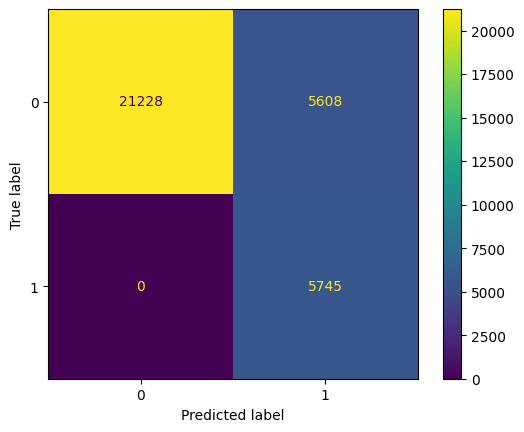

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier


preprocessador = ColumnTransformer( transformers=[ ("onehot", OneHotEncoder(drop="first"), colunas_onehot), ("ordinal", OrdinalEncoder(categories=ordem_risco), coluna_ordinal) ], remainder="passthrough" # Mantém colunas numéricas )
)

# modelo = Pipeline(steps=[
#     ("preprocessamento", preprocessador),
#     ("arvore", DecisionTreeClassifier(max_depth=None,
#     min_samples_leaf=20,
#     class_weight="balanced",
#     random_state=42)
# )
# ])

from lightgbm import LGBMClassifier

modelo = Pipeline(steps=[
    ("preprocessamento", preprocessador),
    ("lgbm", LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        num_leaves=31,
        class_weight="balanced",
        random_state=42
    ))
])


X = df.drop(columns=['historico_inadimplencia'])
y = df['historico_inadimplencia']

avaliar_modelo(X, y, modo="cruzada", modelo=modelo)

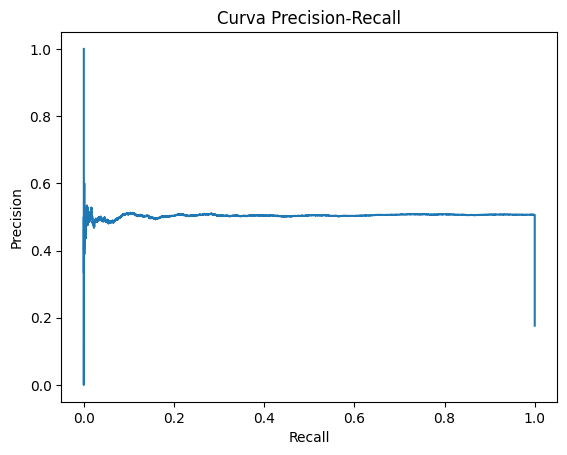

In [ ]:
from sklearn.metrics import precision_recall_curve, PrecisionRecallDisplay
import matplotlib.pyplot as plt

# Gerar probabilidades usando validação cruzada
y_scores = cross_val_predict(
    modelo, 
    X, 
    y, 
    cv=5, 
    method="predict_proba"
)

# Pegamos a probabilidade da classe positiva
# Para problema binário seria [:,1]
# Para Iris (3 classes) precisamos escolher uma classe específica
classe_interesse = 1
y_scores_classe = y_scores[:, classe_interesse]

# Criar curva Precision-Recall
precision, recall, thresholds = precision_recall_curve(
    (y == classe_interesse).astype(int), 
    y_scores_classe
)

# Plotar gráfico
plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curva Precision-Recall")
plt.show()

In [ ]:
# =========================
# 9️⃣ VISUALIZAR ÁRVORE
# =========================
plt.figure(figsize=(10,6))
plot_tree(
    modelo,
    feature_names=df.feature_names,
    class_names=df.target_names,
    filled=True
)
plt.show()

AttributeError: 'DataFrame' object has no attribute 'feature_names'

<Figure size 1000x600 with 0 Axes>